In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

data = [
    ("Payment keeps failing", "negative", ["payment"]),
    ("The application is very slow", "negative", ["performance"]),
    ("I love the new dashboard", "positive", ["ui"]),
    ("Support solved my issue quickly", "positive", ["support"]),
    ("Login OTP is not arriving", "negative", ["login"]),
    ("The app is slow and payment fails", "negative", ["performance", "payment"]),
    ("Excellent customer support", "positive", ["support"]),
    ("The service is okay", "neutral", ["general"]),
    ("The latest update is good but payment is failing frequently", "negative", ["payment", "performance"]),
    ("The support team solved my issue very quickly", "positive", ["support"]),
    ("App is extremely slow", "negative", ["performance"]),
    ("The application is okay", "neutral", ["general"]),
    ("Payment gateway crashed during checkout", "negative", ["payment"]),
    ("Login page keeps timing out", "negative", ["login"]),
    ("The new UI looks beautiful", "positive", ["ui"]),
    ("Support team was rude and unhelpful", "negative", ["support"]),
    ("App freezes every time I open it", "negative", ["performance"]),
    ("Payment succeeded but receipt never arrived", "negative", ["payment"]),
    ("OTP arrives fine now, good fix", "positive", ["login"]),
    ("Dashboard redesign is confusing", "negative", ["ui"]),
    ("Customer care resolved my ticket fast", "positive", ["support"]),
    ("Nothing to complain about, works fine", "neutral", ["general"]),
    ("Slow app and OTP delay both happened today", "negative", ["performance", "login"]),
    ("Great job on the payment refund process", "positive", ["payment"]),
]

df = pd.DataFrame(data, columns=["feedback", "sentiment", "categories"])
df.head()

,feedback,sentiment,categories
0,Payment keeps failing,negative,[payment]
1,The application is very slow,negative,[performance]
2,I love the new dashboard,positive,[ui]
3,Support solved my issue quickly,positive,[support]
4,Login OTP is not arriving,negative,[login]


In [2]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

df["clean_feedback"] = df["feedback"].apply(clean_text)
df[["feedback", "clean_feedback"]]

,feedback,clean_feedback
0,Payment keeps failing,payment keeps failing
1,The application is very slow,the application is very slow
2,I love the new dashboard,i love the new dashboard
3,Support solved my issue quickly,support solved my issue quickly
4,Login OTP is not arriving,login otp is not arriving
5,The app is slow and payment fails,the app is slow and payment fails
6,Excellent customer support,excellent customer support
7,The service is okay,the service is okay
8,The latest update is good but payment is faili...,the latest update is good but payment is faili...
9,The support team solved my issue very quickly,the support team solved my issue very quickly


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_feedback"], df["sentiment"], test_size=0.25, random_state=42
)

sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000)),
])
sentiment_model.fit(X_train, y_train)
y_pred = sentiment_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

    negative       0.60      1.00      0.75         3
     neutral       0.00      0.00      0.00         1
    positive       1.00      0.50      0.67         2

    accuracy                           0.67         6
   macro avg       0.53      0.50      0.47         6
weighted avg       0.63      0.67      0.60         6



In [4]:
mlb = MultiLabelBinarizer()
y_cat = mlb.fit_transform(df["categories"])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    df["clean_feedback"], y_cat, test_size=0.25, random_state=42
)

eval_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
Xc_train_vec = eval_vectorizer.fit_transform(Xc_train)
Xc_test_vec = eval_vectorizer.transform(Xc_test)

eval_category_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
eval_category_model.fit(Xc_train_vec, yc_train)
yc_pred = eval_category_model.predict(Xc_test_vec)

print("Category classes:", mlb.classes_)
print("Micro F1:", f1_score(yc_test, yc_pred, average="micro"))
print("Macro F1:", f1_score(yc_test, yc_pred, average="macro"))

# Full-data model — this is the one used for real predictions below
cat_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
Xc_full_vec = cat_vectorizer.fit_transform(df["clean_feedback"])
category_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
category_model.fit(Xc_full_vec, y_cat)

Category classes: ['general' 'login' 'payment' 'performance' 'support' 'ui']
Micro F1: 0.0
Macro F1: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [5]:
def extract_keywords(text, vectorizer, top_n=3):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    scores = vec.toarray()[0]
    terms = vectorizer.get_feature_names_out()
    top_indices = scores.argsort()[::-1][:top_n]
    return [terms[i] for i in top_indices if scores[i] > 0]

extract_keywords("Payment gateway failed after entering the OTP", cat_vectorizer)

['payment gateway', 'gateway', 'otp']

In [6]:
def analyze_feedback(text, threshold=0.3):
    clean = clean_text(text)
    sentiment = sentiment_model.predict([clean])[0]

    cat_vec = cat_vectorizer.transform([clean])
    probs = category_model.predict_proba(cat_vec)[0]
    predicted_categories = [mlb.classes_[i] for i, p in enumerate(probs) if p >= threshold]
    if not predicted_categories:
        predicted_categories = [mlb.classes_[probs.argmax()]]

    keywords = extract_keywords(text, cat_vectorizer)

    print("Feedback:", text)
    print("Sentiment:", sentiment)
    print("Categories:", predicted_categories)
    print("Keywords:", keywords)
    print()

analyze_feedback("The app is very slow and payment keeps failing.")
analyze_feedback("The support team solved my issue very quickly.")

Feedback: The app is very slow and payment keeps failing.
Sentiment: negative
Categories: ['payment', 'performance']
Keywords: ['slow payment', 'payment keeps', 'keeps failing']

Feedback: The support team solved my issue very quickly.
Sentiment: positive
Categories: ['support']
Keywords: ['team solved', 'solved issue', 'support team']



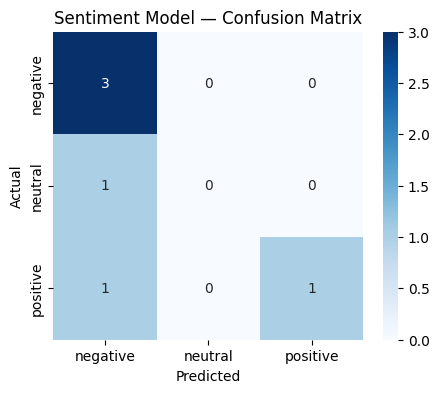

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=sentiment_model.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sentiment_model.classes_,
            yticklabels=sentiment_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Model — Confusion Matrix")
plt.show()

## Design Choices & Results

**Pipeline:** Text Cleaning → TF-IDF (unigram + bigram, English stopwords removed) → Logistic Regression

**Sentiment Classification**
- Accuracy: 0.67 on held-out test split (small dataset — 24 rows total)
- Struggles most on `neutral` class due to fewest training examples

**Category Classification (multi-label)**
- OneVsRestClassifier + Logistic Regression per category
- Used `predict_proba` with a 0.3 threshold instead of default `.predict()`,
  since the default 0.5 cutoff caused every unseen phrasing to return no labels
- Falls back to the single highest-probability category if nothing clears the threshold

**Keyword Extraction**
- TF-IDF term scores from the category vectorizer, top-3 per feedback, English stopwords removed

**Known limitation:** dataset is intentionally small (24 examples) for a beginner-scope
project per the brief — a larger dataset would improve neutral-class recall and
category F1 scores.